In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Phase 1: Generating Stochastic IoT Telemetry Data (Applied Statistics)...")
np.random.seed(42)

# Simulate 100 enterprise Wi-Fi routers over a maximum of 500 hours
num_routers = 100
max_cycles = 500

data = []
for router_id in range(1, num_routers + 1):
    # Randomize the lifespan of each router (between 150 and 500 hours)
    lifespan = np.random.randint(150, max_cycles)

    # Base metrics for a healthy router
    temp_base = 45.0
    mem_base = 20.0
    drop_base = 0.01

    for hour in range(lifespan):
        # Remaining Useful Life (Target Variable)
        rul = lifespan - hour - 1

        # Simulate degradation using exponential curves and statistical noise (Gaussian)
        degradation_factor = (hour / lifespan) ** 2

        cpu_temp = temp_base + (degradation_factor * 40) + np.random.normal(0, 2)
        mem_util = mem_base + (degradation_factor * 70) + np.random.normal(0, 3)
        packet_drop = drop_base + (degradation_factor * 5) + np.random.normal(0, 0.1)

        data.append([router_id, hour, cpu_temp, mem_util, packet_drop, rul])

# Create the DataFrame
columns = ['router_id', 'operating_hour', 'cpu_temp_celsius', 'memory_utilization_percent', 'packet_drop_rate', 'RUL']
df = pd.DataFrame(data, columns=columns)

# Ensure no impossible negative values from the statistical noise
df['packet_drop_rate'] = df['packet_drop_rate'].clip(lower=0)

print("Phase 2: Feature Engineering (Calculus/Rate of Change)...")
# We need to give the neural network context of how fast things are degrading.
# We will calculate the rolling mean and the derivative (rate of change) over a 5-hour window.

def calculate_rolling_features(group):
    # Rolling averages to smooth out the Gaussian noise
    group['temp_rolling_mean'] = group['cpu_temp_celsius'].rolling(window=5, min_periods=1).mean()

    # Discrete derivative (calculus concept: dy/dx) to measure how FAST temperature is rising
    group['temp_rate_of_change'] = group['cpu_temp_celsius'].diff().fillna(0)
    return group

df = df.groupby('router_id', group_keys=False).apply(calculate_rolling_features)

# Define Features (X) and Target (y)
features = ['operating_hour', 'cpu_temp_celsius', 'memory_utilization_percent',
            'packet_drop_rate', 'temp_rolling_mean', 'temp_rate_of_change']

X = df[features]
y = df['RUL']

# Statistical Scaling (MinMax Scaling to bound inputs between 0 and 1 for neural network stability)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Generated {len(df)} hours of telemetry data across {num_routers} simulated IoT devices.")
print(f"Feature matrix shape: {X_scaled.shape}")
print("Ready for Deep Learning (Regression).")

Phase 1: Generating Stochastic IoT Telemetry Data (Applied Statistics)...
Phase 2: Feature Engineering (Calculus/Rate of Change)...
Generated 32397 hours of telemetry data across 100 simulated IoT devices.
Feature matrix shape: (32397, 6)
Ready for Deep Learning (Regression).


/tmp/ipykernel_267/1378037687.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('router_id', group_keys=False).apply(calculate_rolling_features)


Phase 3: Building the Deep Learning Regression Model...
Training the Neural Network via Backpropagation...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


671/671 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 27991.6484 - mae: 129.6594 - val_loss: 2515.5322 - val_mae: 36.6508
Epoch 2/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3320.4871 - mae: 41.3131 - val_loss: 1793.8145 - val_mae: 28.7232
Epoch 3/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2614.2817 - mae: 33.8905 - val_loss: 1576.5765 - val_mae: 25.1706
Epoch 4/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2256.1360 - mae: 30.6740 - val_loss: 1512.1874 - val_mae: 23.8797
Epoch 5/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2187.5964 - mae: 29.5639 - val_loss: 1506.6752 - val_mae: 23.8183
Epoch 6/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2129.1904 - mae: 28.9464 - val_loss: 1466.8829 - val_mae: 22.9741
Epoch 7/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2079.7205 - mae: 28.0312 - val_loss: 1448.2734 - val_mae: 22.7623
Epoch 8/20
671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2050.5359 - mae: 27.4792 - val_loss: 1464.3862 - val_mae: 22.6767
E

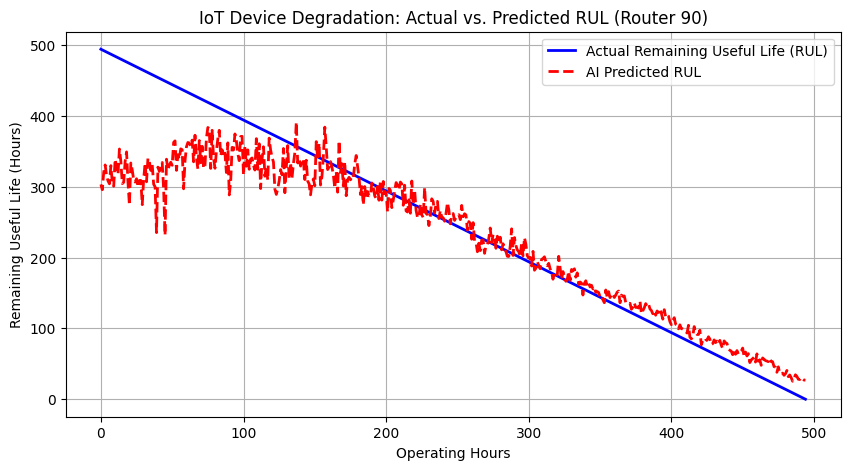

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print("Phase 3: Building the Deep Learning Regression Model...")

# 1. Train/Test Split (Crucial for time-series/IoT)
# We must split by router_id to avoid data leakage.
# Train on routers 1-80, test on unseen routers 81-100.
train_mask = df['router_id'] <= 80
test_mask = df['router_id'] > 80

X_train = X_scaled[train_mask]
y_train = y[train_mask]
X_test = X_scaled[test_mask]
y_test = y[test_mask]

# 2. Define the Neural Network Architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Dropout layer prevents the network from memorizing the noise
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear') # Linear activation because we are predicting a continuous number (hours)
])

# 3. Compile the Model using Calculus
# We use the Adam optimizer (Adaptive Moment Estimation) to compute adaptive learning rates for each parameter.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# 4. Train the Model
print("Training the Neural Network via Backpropagation...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nPhase 4: Evaluation and Visualization...")
# 5. Predict on the unseen test routers
y_pred = model.predict(X_test)

# 6. Calculate Statistical Error Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Final Model Performance on Unseen Edge Devices ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} hours")

# 7. Visualize Actual vs. Predicted Degradation for Router 90
router_90_mask = df[test_mask]['router_id'] == 90
y_test_90 = y_test[router_90_mask].values
y_pred_90 = y_pred[router_90_mask]

plt.figure(figsize=(10, 5))
plt.plot(y_test_90, label='Actual Remaining Useful Life (RUL)', color='blue', linewidth=2)
plt.plot(y_pred_90, label='AI Predicted RUL', color='red', linestyle='dashed', linewidth=2)
plt.title('IoT Device Degradation: Actual vs. Predicted RUL (Router 90)')
plt.xlabel('Operating Hours')
plt.ylabel('Remaining Useful Life (Hours)')
plt.legend()
plt.grid(True)
plt.show()